# 第12章: 一般の分布に関する検定法

## 学習目標
- カイ二乗適合度検定を理解し適用できる
- コルモゴロフ・スミルノフ検定を理解する
- 分割表の独立性検定を実行できる

## 📋 学習メタ情報

### 推定学習時間
**110〜140分**

### 難易度
**★★★★☆** (5段階中4)

---

## 🎯 なぜこの章を学ぶのか？

正規性の前提が満たされない場合、尤度比検定やワルド検定などの一般的な手法が必要です。これらは最尤推定に基づく統一的な枠組みを提供します。

### 実世界での応用

**ロジスティック回帰**: 尤度比検定で変数の有意性を検定

**ポアソン回帰**: カウントデータのモデリングで係数を検定

**一般化線形モデル**: 様々な分布族に対応した検定

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 12.1 カイ二乗適合度検定

### 検定統計量
観測度数 $O_i$ と期待度数 $E_i$ について:
$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$

### 漸近分布
$H_0$ の下で:
$$\chi^2 \xrightarrow{d} \chi^2(k-1-m)$$

ここで $m$ は推定したパラメータの数。

カイ二乗適合度検定: サイコロの公正性
H0: サイコロは公正（各目の確率 = 1/6）

総投数: 600

    1    2    3    4    5    6
O: [ 95 105  98 100 103  99]
E: [100 100 100 100 100 100]

χ²統計量 = 0.640
自由度: 5
p値 = 0.9861

SciPy結果: χ² = 0.640, p = 0.9861


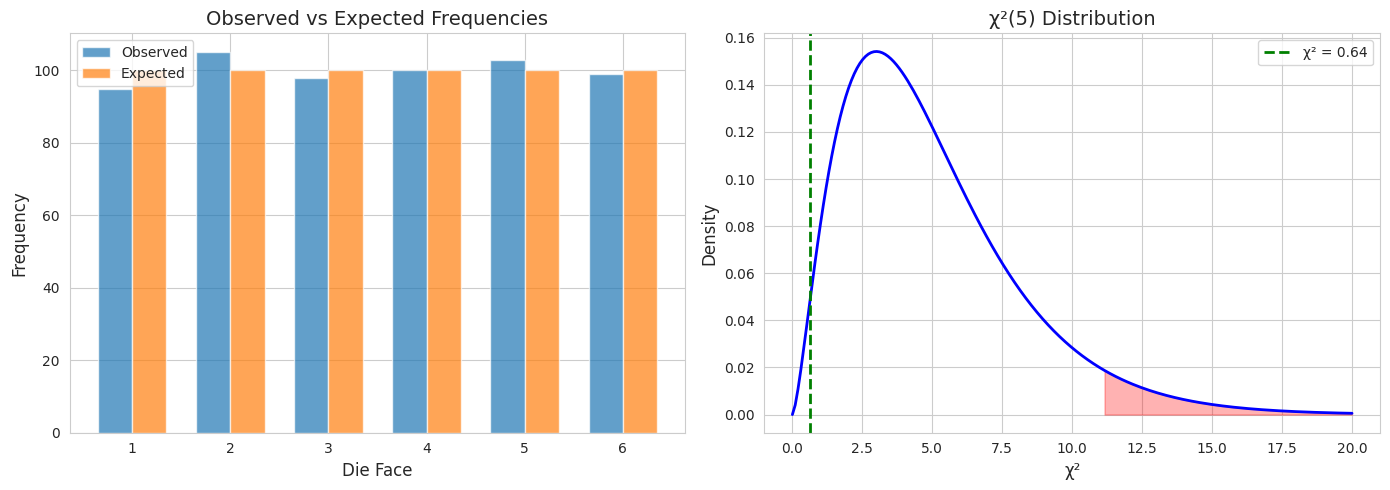

In [2]:
# カイ二乗適合度検定の例：サイコロの公正性
np.random.seed(123)

# Observed frequencies (slightly biased die)
n_rolls = 600
observed = np.array([95, 105, 98, 100, 103, 99])

# Expected frequencies under H0 (fair die)
expected = np.array([n_rolls/6] * 6)

# Chi-squared statistic
chi2_stat = np.sum((observed - expected)**2 / expected)
df = 6 - 1  # k - 1
p_value = 1 - stats.chi2.cdf(chi2_stat, df)

print("カイ二乗適合度検定: サイコロの公正性")
print("="*50)
print(f"H0: サイコロは公正（各目の確率 = 1/6）")
print(f"\n総投数: {n_rolls}")
print(f"\n    1    2    3    4    5    6")
print(f"O: {observed}")
print(f"E: {expected.astype(int)}")
print(f"\nχ²統計量 = {chi2_stat:.3f}")
print(f"自由度: {df}")
print(f"p値 = {p_value:.4f}")

# Compare with scipy
chi2_scipy, p_scipy = stats.chisquare(observed, expected)
print(f"\nSciPy結果: χ² = {chi2_scipy:.3f}, p = {p_scipy:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
x = np.arange(1, 7)
width = 0.35
axes[0].bar(x - width/2, observed, width, label='Observed', alpha=0.7)
axes[0].bar(x + width/2, expected, width, label='Expected', alpha=0.7)
axes[0].set_xlabel('Die Face', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Observed vs Expected Frequencies', fontsize=14)
axes[0].legend()

# Chi-squared distribution
x_chi = np.linspace(0, 20, 200)
axes[1].plot(x_chi, stats.chi2.pdf(x_chi, df), 'b-', linewidth=2)
axes[1].axvline(chi2_stat, color='green', linestyle='--', linewidth=2, label=f'χ² = {chi2_stat:.2f}')
chi2_crit = stats.chi2.ppf(0.95, df)
axes[1].fill_between(x_chi[x_chi > chi2_crit], stats.chi2.pdf(x_chi[x_chi > chi2_crit], df), 
                     alpha=0.3, color='red')
axes[1].set_xlabel('χ²', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title(f'χ²({df}) Distribution', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

カイ二乗適合度検定: ポアソン分布への適合
H0: データはポアソン分布に従う

サンプルサイズ: 200
推定λ: 3.08

値:     [0, 1, 2, 3, 4, 5, 6, 7] + [8+]
O:      [ 9 28 37 57 34 18  9  3  5]
E:      [ 9.2 28.3 43.6 44.8 34.5 21.2 10.9  4.8  2.7]

χ²統計量 = 7.705
自由度: 7
p値 = 0.3593


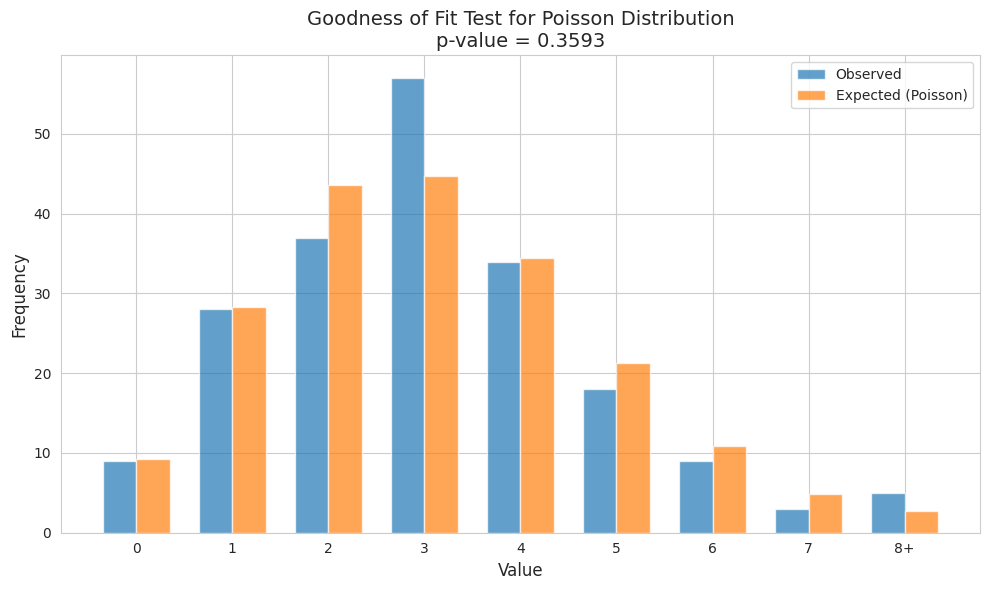

In [3]:
# 適合度検定：ポアソン分布への適合
np.random.seed(456)

# Generate data from Poisson distribution
n = 200
true_lambda = 3
data = np.random.poisson(true_lambda, n)

# Count frequencies
max_val = 8
observed = np.array([np.sum(data == i) for i in range(max_val)])
observed = np.append(observed, np.sum(data >= max_val))  # Last bin: >= max_val

# Expected frequencies under H0: Poisson with estimated lambda
lambda_mle = np.mean(data)
expected = np.array([n * stats.poisson.pmf(i, lambda_mle) for i in range(max_val)])
expected = np.append(expected, n * (1 - stats.poisson.cdf(max_val - 1, lambda_mle)))

# Chi-squared test (df = k - 1 - 1, because we estimated lambda)
chi2_stat = np.sum((observed - expected)**2 / expected)
df = len(observed) - 1 - 1  # k - 1 - m (m=1 for lambda)
p_value = 1 - stats.chi2.cdf(chi2_stat, df)

print("カイ二乗適合度検定: ポアソン分布への適合")
print("="*50)
print(f"H0: データはポアソン分布に従う")
print(f"\nサンプルサイズ: {n}")
print(f"推定λ: {lambda_mle:.2f}")
print(f"\n値:     {list(range(max_val))} + [{max_val}+]")
print(f"O:      {observed}")
print(f"E:      {np.round(expected, 1)}")
print(f"\nχ²統計量 = {chi2_stat:.3f}")
print(f"自由度: {df}")
print(f"p値 = {p_value:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

labels = [str(i) for i in range(max_val)] + [f'{max_val}+']
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, observed, width, label='Observed', alpha=0.7)
ax.bar(x + width/2, expected, width, label='Expected (Poisson)', alpha=0.7)
ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'Goodness of Fit Test for Poisson Distribution\np-value = {p_value:.4f}', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()

## 12.2 コルモゴロフ・スミルノフ検定

### 一標本KS検定
経験分布関数 $F_n(x)$ と理論分布関数 $F_0(x)$ の最大差:
$$D_n = \sup_x |F_n(x) - F_0(x)|$$

### 二標本KS検定
二つの経験分布関数の最大差:
$$D_{n,m} = \sup_x |F_n(x) - G_m(x)|$$

一標本コルモゴロフ・スミルノフ検定
H0: データは標準正規分布に従う

サンプルサイズ: 50
D統計量 = 0.1195
p値 = 0.4389


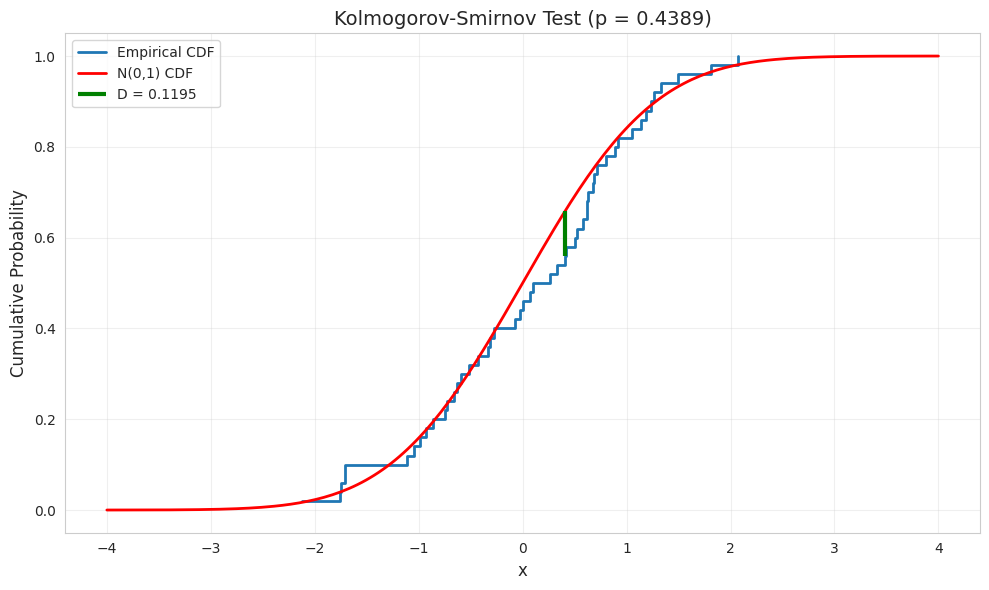

In [4]:
# 一標本KS検定：正規性の検定
np.random.seed(789)

# Generate sample
n = 50
sample = np.random.normal(0, 1, n)

# KS test against standard normal
d_stat, p_value = stats.kstest(sample, 'norm')

print("一標本コルモゴロフ・スミルノフ検定")
print("="*50)
print(f"H0: データは標準正規分布に従う")
print(f"\nサンプルサイズ: {n}")
print(f"D統計量 = {d_stat:.4f}")
print(f"p値 = {p_value:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Empirical CDF
sample_sorted = np.sort(sample)
ecdf = np.arange(1, n + 1) / n
ax.step(sample_sorted, ecdf, where='post', label='Empirical CDF', linewidth=2)

# Theoretical CDF
x = np.linspace(-4, 4, 200)
ax.plot(x, stats.norm.cdf(x), 'r-', label='N(0,1) CDF', linewidth=2)

# Show maximum difference
theoretical_cdf = stats.norm.cdf(sample_sorted)
diff = np.abs(ecdf - theoretical_cdf)
max_idx = np.argmax(diff)
ax.vlines(sample_sorted[max_idx], theoretical_cdf[max_idx], ecdf[max_idx], 
          colors='green', linewidth=3, label=f'D = {d_stat:.4f}')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Cumulative Probability', fontsize=12)
ax.set_title(f'Kolmogorov-Smirnov Test (p = {p_value:.4f})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

KS検定: 指数分布 vs 正規分布
D統計量 = 0.1903
p値 = 0.0465

結論: H0を棄却する


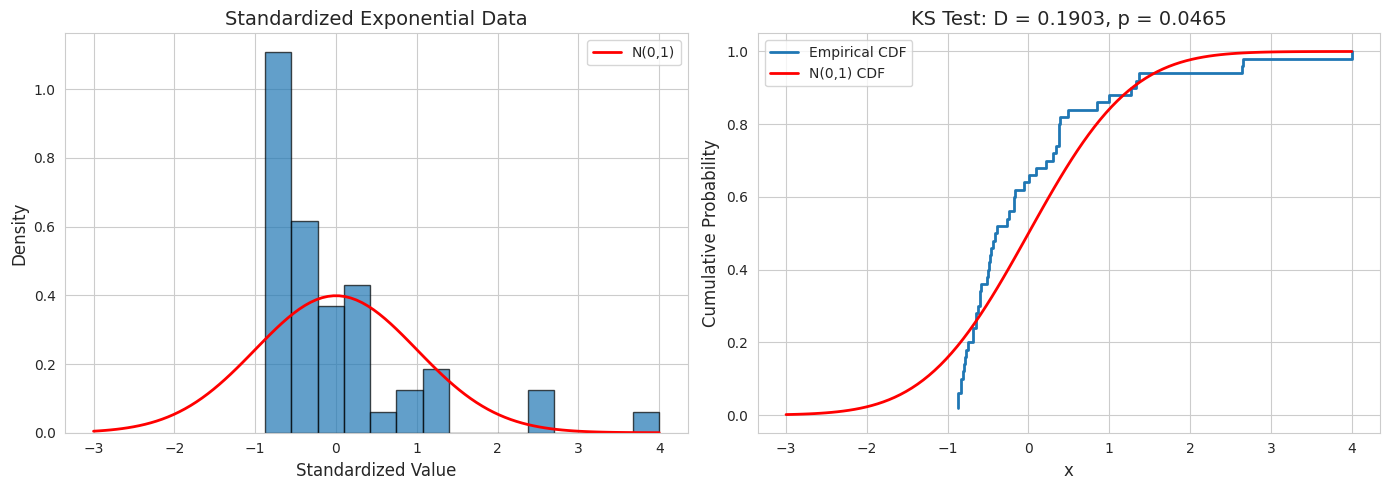

In [5]:
# 非正規データでのKS検定
np.random.seed(111)

# Generate non-normal data (exponential)
n = 50
sample_exp = np.random.exponential(1, n)

# KS test against normal
# Need to standardize for comparison
sample_std = (sample_exp - np.mean(sample_exp)) / np.std(sample_exp)
d_stat, p_value = stats.kstest(sample_std, 'norm')

print("KS検定: 指数分布 vs 正規分布")
print("="*50)
print(f"D統計量 = {d_stat:.4f}")
print(f"p値 = {p_value:.4f}")
print(f"\n結論: H0を{'棄却する' if p_value < 0.05 else '棄却しない'}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(sample_std, bins=15, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(-3, 4, 100)
axes[0].plot(x, stats.norm.pdf(x), 'r-', linewidth=2, label='N(0,1)')
axes[0].set_xlabel('Standardized Value', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Standardized Exponential Data', fontsize=14)
axes[0].legend()

# CDF comparison
sample_sorted = np.sort(sample_std)
ecdf = np.arange(1, n + 1) / n
axes[1].step(sample_sorted, ecdf, where='post', label='Empirical CDF', linewidth=2)
axes[1].plot(x, stats.norm.cdf(x), 'r-', label='N(0,1) CDF', linewidth=2)
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].set_title(f'KS Test: D = {d_stat:.4f}, p = {p_value:.4f}', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

二標本コルモゴロフ・スミルノフ検定
H0: 二つの標本は同じ分布から得られた

サンプル1: n1 = 40
サンプル2: n2 = 50

D統計量 = 0.2500
p値 = 0.1055


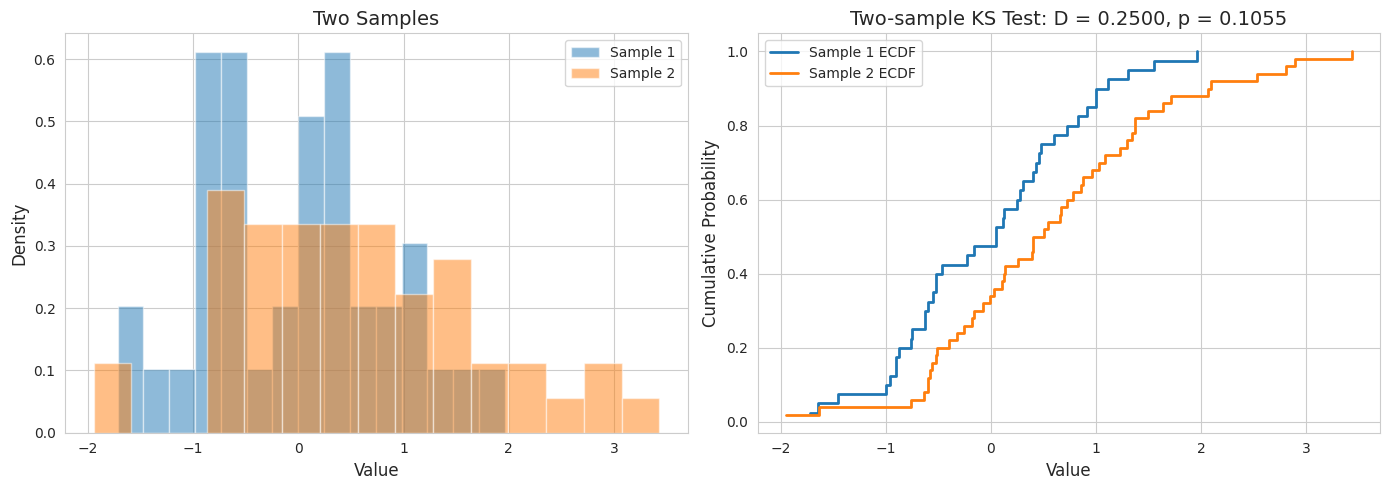

In [6]:
# 二標本KS検定
np.random.seed(222)

# Two samples from different distributions
n1, n2 = 40, 50
sample1 = np.random.normal(0, 1, n1)
sample2 = np.random.normal(0.5, 1.2, n2)

# Two-sample KS test
d_stat, p_value = stats.ks_2samp(sample1, sample2)

print("二標本コルモゴロフ・スミルノフ検定")
print("="*50)
print(f"H0: 二つの標本は同じ分布から得られた")
print(f"\nサンプル1: n1 = {n1}")
print(f"サンプル2: n2 = {n2}")
print(f"\nD統計量 = {d_stat:.4f}")
print(f"p値 = {p_value:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograms
axes[0].hist(sample1, bins=15, density=True, alpha=0.5, label='Sample 1')
axes[0].hist(sample2, bins=15, density=True, alpha=0.5, label='Sample 2')
axes[0].set_xlabel('Value', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Two Samples', fontsize=14)
axes[0].legend()

# ECDFs
sorted1 = np.sort(sample1)
sorted2 = np.sort(sample2)
ecdf1 = np.arange(1, n1 + 1) / n1
ecdf2 = np.arange(1, n2 + 1) / n2

axes[1].step(sorted1, ecdf1, where='post', label='Sample 1 ECDF', linewidth=2)
axes[1].step(sorted2, ecdf2, where='post', label='Sample 2 ECDF', linewidth=2)
axes[1].set_xlabel('Value', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].set_title(f'Two-sample KS Test: D = {d_stat:.4f}, p = {p_value:.4f}', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 12.3 分割表の独立性検定

### 検定統計量
$r \times c$ 分割表について:
$$\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

期待度数: $E_{ij} = \frac{R_i \times C_j}{n}$

### 自由度
$$df = (r-1)(c-1)$$

In [7]:
# 独立性検定の例：性別と好み
# Observed frequencies
observed = np.array([
    [30, 20, 10],  # Male: Product A, B, C
    [20, 40, 30]   # Female: Product A, B, C
])

# Calculate expected frequencies
row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)
total = observed.sum()

expected = np.outer(row_totals, col_totals) / total

# Chi-squared statistic
chi2_stat = np.sum((observed - expected)**2 / expected)
df = (observed.shape[0] - 1) * (observed.shape[1] - 1)
p_value = 1 - stats.chi2.cdf(chi2_stat, df)

print("独立性のカイ二乗検定")
print("="*50)
print(f"H0: 性別と製品の好みは独立")
print(f"\n観測度数:")
print(f"        A    B    C  | Total")
print(f"Male   {observed[0,0]:3d}  {observed[0,1]:3d}  {observed[0,2]:3d}  | {row_totals[0]:3d}")
print(f"Female {observed[1,0]:3d}  {observed[1,1]:3d}  {observed[1,2]:3d}  | {row_totals[1]:3d}")
print(f"Total  {col_totals[0]:3d}  {col_totals[1]:3d}  {col_totals[2]:3d}  | {total:3d}")
print(f"\n期待度数:")
print(np.round(expected, 1))
print(f"\nχ²統計量 = {chi2_stat:.3f}")
print(f"自由度: {df}")
print(f"p値 = {p_value:.4f}")

# Compare with scipy
chi2_scipy, p_scipy, dof, expected_scipy = stats.chi2_contingency(observed)
print(f"\nSciPy結果: χ² = {chi2_scipy:.3f}, p = {p_scipy:.4f}")

独立性のカイ二乗検定
H0: 性別と製品の好みは独立

観測度数:
        A    B    C  | Total
Male    30   20   10  |  60
Female  20   40   30  |  90
Total   50   60   40  | 150

期待度数:
[[20. 24. 16.]
 [30. 36. 24.]]

χ²統計量 = 13.194
自由度: 2
p値 = 0.0014

SciPy結果: χ² = 13.194, p = 0.0014


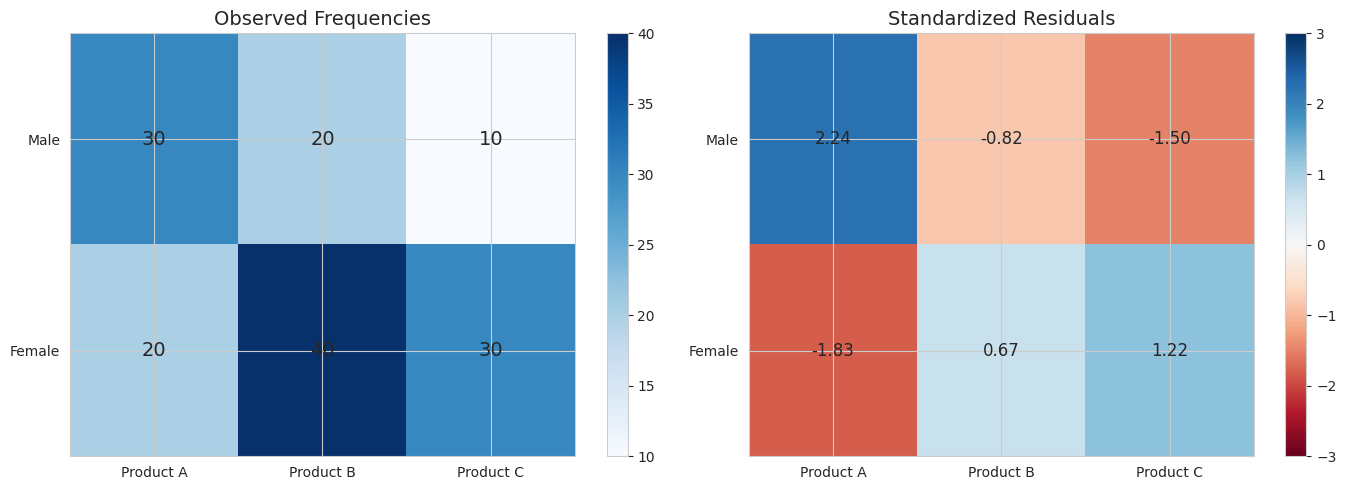

In [8]:
# 独立性検定の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Observed frequencies heatmap
im1 = axes[0].imshow(observed, cmap='Blues', aspect='auto')
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Product A', 'Product B', 'Product C'])
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Male', 'Female'])
axes[0].set_title('Observed Frequencies', fontsize=14)

# Add text annotations
for i in range(2):
    for j in range(3):
        axes[0].text(j, i, str(observed[i, j]), ha='center', va='center', fontsize=14)

plt.colorbar(im1, ax=axes[0])

# Residuals (O - E) / sqrt(E)
residuals = (observed - expected) / np.sqrt(expected)
im2 = axes[1].imshow(residuals, cmap='RdBu', aspect='auto', vmin=-3, vmax=3)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Product A', 'Product B', 'Product C'])
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Male', 'Female'])
axes[1].set_title('Standardized Residuals', fontsize=14)

# Add text annotations
for i in range(2):
    for j in range(3):
        axes[1].text(j, i, f'{residuals[i, j]:.2f}', ha='center', va='center', fontsize=12)

plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

In [9]:
# より大きな分割表の例
np.random.seed(333)

# 3x4 contingency table
observed = np.array([
    [20, 30, 25, 15],   # Group A
    [35, 20, 30, 25],   # Group B
    [25, 35, 20, 30]    # Group C
])

# Chi-squared test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)

print("3×4分割表の独立性検定")
print("="*50)
print(f"\n観測度数:")
print(observed)
print(f"\n期待度数:")
print(np.round(expected, 1))
print(f"\nχ²統計量 = {chi2_stat:.3f}")
print(f"自由度: {dof}")
print(f"p値 = {p_value:.4f}")

# Effect size (Cramér's V)
n = observed.sum()
min_dim = min(observed.shape[0] - 1, observed.shape[1] - 1)
cramers_v = np.sqrt(chi2_stat / (n * min_dim))
print(f"\nCramér's V = {cramers_v:.3f}")

3×4分割表の独立性検定

観測度数:
[[20 30 25 15]
 [35 20 30 25]
 [25 35 20 30]]

期待度数:
[[23.2 24.7 21.8 20.3]
 [28.4 30.2 26.6 24.8]
 [28.4 30.2 26.6 24.8]]

χ²統計量 = 12.760
自由度: 6
p値 = 0.0470

Cramér's V = 0.143


## 12.4 正確検定（フィッシャーの正確検定）

小さなサンプルサイズの場合、カイ二乗近似が不正確になる。フィッシャーの正確検定は、2×2分割表で周辺度数を固定した下での正確な確率を計算する。

In [10]:
# フィッシャーの正確検定
# Small sample 2x2 table
observed_small = np.array([
    [8, 2],
    [1, 5]
])

# Chi-squared test (may be inaccurate for small samples)
chi2_stat, p_chi2, dof, expected = stats.chi2_contingency(observed_small)

# Fisher's exact test
odds_ratio, p_fisher = stats.fisher_exact(observed_small)

print("小標本の2×2分割表検定")
print("="*50)
print(f"\n観測度数:")
print(observed_small)
print(f"\n期待度数:")
print(np.round(expected, 2))
print(f"\nカイ二乗検定:")
print(f"  χ² = {chi2_stat:.3f}, p = {p_chi2:.4f}")
print(f"\nフィッシャーの正確検定:")
print(f"  オッズ比 = {odds_ratio:.3f}")
print(f"  p値 = {p_fisher:.4f}")
print(f"\n注意: 期待度数が5未満のセルがある場合、正確検定を使用すべき")

小標本の2×2分割表検定

観測度数:
[[8 2]
 [1 5]]

期待度数:
[[5.62 4.38]
 [3.38 2.62]]

カイ二乗検定:
  χ² = 3.810, p = 0.0510

フィッシャーの正確検定:
  オッズ比 = 20.000
  p値 = 0.0350

注意: 期待度数が5未満のセルがある場合、正確検定を使用すべき


## 12.5 適合度検定と独立性検定の比較

| 特徴 | 適合度検定 | 独立性検定 |
|------|------------|------------|
| 目的 | 観測分布が理論分布に適合するか | 2変数が独立か |
| データ | 1次元度数 | 2次元分割表 |
| 自由度 | k - 1 - m | (r-1)(c-1) |

In [11]:
# 検定のType I errorの検証
n_simulations = 5000
alpha = 0.05

# Chi-squared goodness of fit test
type1_gof = 0
n = 100
p = [0.2, 0.3, 0.25, 0.25]  # True probabilities

for _ in range(n_simulations):
    observed = np.random.multinomial(n, p)
    expected = n * np.array(p)
    chi2, pval = stats.chisquare(observed, expected)
    if pval < alpha:
        type1_gof += 1

# Chi-squared independence test
type1_ind = 0

for _ in range(n_simulations):
    # Generate under independence
    row_p = [0.4, 0.6]
    col_p = [0.3, 0.4, 0.3]
    observed = np.zeros((2, 3))
    for i in range(n):
        row = np.random.choice(2, p=row_p)
        col = np.random.choice(3, p=col_p)
        observed[row, col] += 1
    
    chi2, pval, _, _ = stats.chi2_contingency(observed)
    if pval < alpha:
        type1_ind += 1

print("Type I Error Rate Verification")
print("="*50)
print(f"Nominal α = {alpha}")
print(f"\nGoodness of fit test: {type1_gof/n_simulations:.4f}")
print(f"Independence test:    {type1_ind/n_simulations:.4f}")

Type I Error Rate Verification
Nominal α = 0.05

Goodness of fit test: 0.0552
Independence test:    0.0530


## 12.6 練習問題

### 問題1
ある工場で製造された部品の不良品数を調べたところ、以下のデータが得られた。この不良品数がポアソン分布に従うかどうかを有意水準5%で検定せよ。

| 不良品数 | 0 | 1 | 2 | 3以上 |
|----------|---|---|---|-------|
| 度数 | 42 | 35 | 15 | 8 |

### 問題2
以下の分割表について、喫煙習慣と肺疾患の間に関連があるかどうかを有意水準5%で検定せよ。

|  | 肺疾患あり | 肺疾患なし |
|--|------------|------------|
| 喫煙者 | 60 | 40 |
| 非喫煙者 | 30 | 70 |

### 問題3
100個のデータが標準正規分布から得られたかどうかをKS検定で検定せよ。データの標本平均は0.15、標本標準偏差は1.05である。

In [12]:
# 問題1の解答
print("問題1: ポアソン分布への適合度検定")
print("="*50)

observed = np.array([42, 35, 15, 8])
n = observed.sum()  # 100

# Estimate lambda
# mean = (0*42 + 1*35 + 2*15 + 3*8) / 100
mean_defects = (0*42 + 1*35 + 2*15 + 3*8) / n
print(f"\n推定λ = {mean_defects:.2f}")

# Expected frequencies
lambda_est = mean_defects
e0 = n * stats.poisson.pmf(0, lambda_est)
e1 = n * stats.poisson.pmf(1, lambda_est)
e2 = n * stats.poisson.pmf(2, lambda_est)
e3plus = n * (1 - stats.poisson.cdf(2, lambda_est))
expected = np.array([e0, e1, e2, e3plus])

print(f"\n    0    1    2   3+")
print(f"O: {observed}")
print(f"E: {np.round(expected, 1)}")

# Chi-squared test (df = 4 - 1 - 1 = 2)
chi2_stat = np.sum((observed - expected)**2 / expected)
df = 4 - 1 - 1
p_value = 1 - stats.chi2.cdf(chi2_stat, df)

print(f"\nχ² = {chi2_stat:.3f}")
print(f"自由度: {df}")
print(f"p値 = {p_value:.4f}")
print(f"\n結論: H0を{'棄却する' if p_value < 0.05 else '棄却しない（ポアソン分布に適合）'}")

問題1: ポアソン分布への適合度検定

推定λ = 0.89

    0    1    2   3+
O: [42 35 15  8]
E: [41.1 36.5 16.3  6.1]

χ² = 0.761
自由度: 2
p値 = 0.6835

結論: H0を棄却しない（ポアソン分布に適合）


In [13]:
# 問題2の解答
print("問題2: 独立性のカイ二乗検定")
print("="*50)

observed = np.array([
    [60, 40],  # Smoker
    [30, 70]   # Non-smoker
])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)

print(f"\n観測度数:")
print(f"         疾患あり 疾患なし")
print(f"喫煙者     {observed[0,0]:3d}     {observed[0,1]:3d}")
print(f"非喫煙者   {observed[1,0]:3d}     {observed[1,1]:3d}")

print(f"\n期待度数:")
print(np.round(expected, 1))

print(f"\nχ² = {chi2_stat:.3f}")
print(f"自由度: {dof}")
print(f"p値 = {p_value:.4f}")

# Effect size (Phi coefficient for 2x2 table)
n = observed.sum()
phi = np.sqrt(chi2_stat / n)
print(f"\nファイ係数 = {phi:.3f}")
print(f"\n結論: H0を{'棄却する（喫煙と肺疾患に関連あり）' if p_value < 0.05 else '棄却しない'}")

問題2: 独立性のカイ二乗検定

観測度数:
         疾患あり 疾患なし
喫煙者      60      40
非喫煙者    30      70

期待度数:
[[45. 55.]
 [45. 55.]]

χ² = 16.990
自由度: 1
p値 = 0.0000

ファイ係数 = 0.291

結論: H0を棄却する（喫煙と肺疾患に関連あり）


In [14]:
# 問題3の解答
print("問題3: KS検定による正規性の検定")
print("="*50)

# Generate data with given statistics
np.random.seed(999)
n = 100
sample = np.random.normal(0.15, 1.05, n)

# Adjust to match given statistics exactly
sample = (sample - np.mean(sample)) / np.std(sample) * 1.05 + 0.15

print(f"\nサンプルサイズ: {n}")
print(f"標本平均: {np.mean(sample):.2f}")
print(f"標本標準偏差: {np.std(sample):.2f}")

# KS test against standard normal
d_stat, p_value = stats.kstest(sample, 'norm')

print(f"\n標準正規分布への適合:")
print(f"D = {d_stat:.4f}")
print(f"p値 = {p_value:.4f}")

# Also test against normal with estimated parameters
d_stat2, p_value2 = stats.kstest(sample, 'norm', args=(np.mean(sample), np.std(sample)))
print(f"\n推定パラメータを用いた正規分布への適合:")
print(f"D = {d_stat2:.4f}")
print(f"p値 = {p_value2:.4f}")

print(f"\n結論: データは標準正規分布に{'従わない' if p_value < 0.05 else '従う可能性あり'}")

問題3: KS検定による正規性の検定

サンプルサイズ: 100
標本平均: 0.15
標本標準偏差: 1.05

標準正規分布への適合:
D = 0.0960
p値 = 0.2965

推定パラメータを用いた正規分布への適合:
D = 0.0425
p値 = 0.9902

結論: データは標準正規分布に従う可能性あり


## ⚠️ よくある間違いと解決策

### ❌ サンプルサイズと漸近理論
**正しい理解:** nが小さいと漸近理論が成立しない
**解決策:** n≥30程度が目安だが、分布によって異なる

### ❌ 多重検定の問題
**正しい理解:** 複数の検定を行うと第1種の誤りが増大
**解決策:** Bonferroni補正などで調整

---

## 📝 理解度チェッククイズ

### 問題 1
尤度比検定の統計量は何に従うか？

### 問題 2
Wald検定とスコア検定の違いは？

---

## 📚 まとめ

お疲れ様でした！この章の内容は統計的推論の核心部分です。

---